# Time Series Forecasting of Household Electric Power Consumption
## A Comparative Study of ARIMA and LSTM Models

# **DATA LOADING**



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Load dataset
data = fetch_ucirepo(id=235)

# Features
df = data.data.features

df.head()

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,25979


In [ ]:
df = df.replace('?', np.nan)

In [ ]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## **DATA PREPROCESSNG**

In [ ]:
df = data.data.features.copy()

# Convert everything to string first (safe step)
df = df.astype(str)

# Now create datetime
df['datetime'] = pd.to_datetime(
    df['Date'].str.strip() + ' ' + df['Time'].str.strip(),
    errors='coerce'
)

# Set index
df = df.set_index('datetime')

# Drop old columns
df = df.drop(['Date', 'Time'], axis=1)

/tmp/ipykernel_931/817407664.py:7: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(


In [ ]:
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [ ]:
df = df.dropna()

In [ ]:
import numpy as np

df = df.replace('?', np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## TARGET **VARIABLE**

In [ ]:
target = df['Global_active_power']

# **FIRST VISUALIZATION**

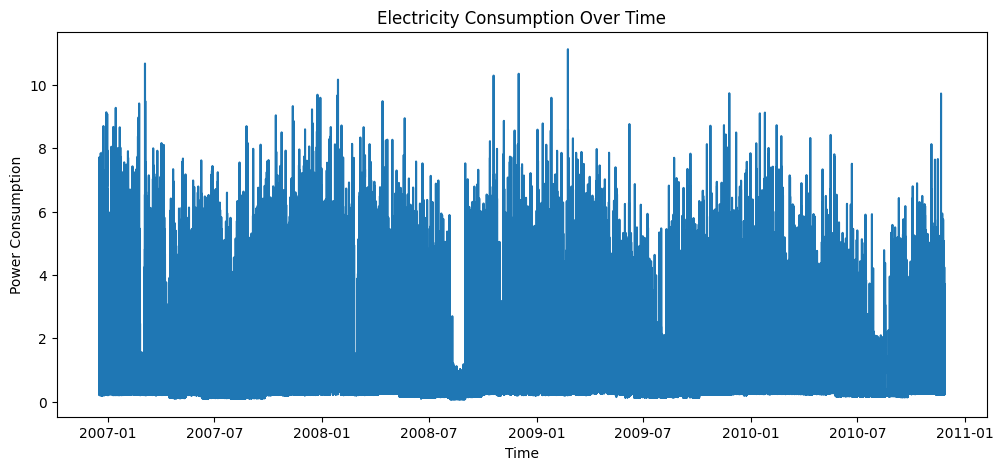

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(target)
plt.title("Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.show()

# **RESAMPLE DATA**

In [ ]:
daily_data = target.resample('D').mean()

# **EXPLORATORY DATA ANALYSIS (EDA)**

#FINAL PLOT (CLEAN TIME SERIES)

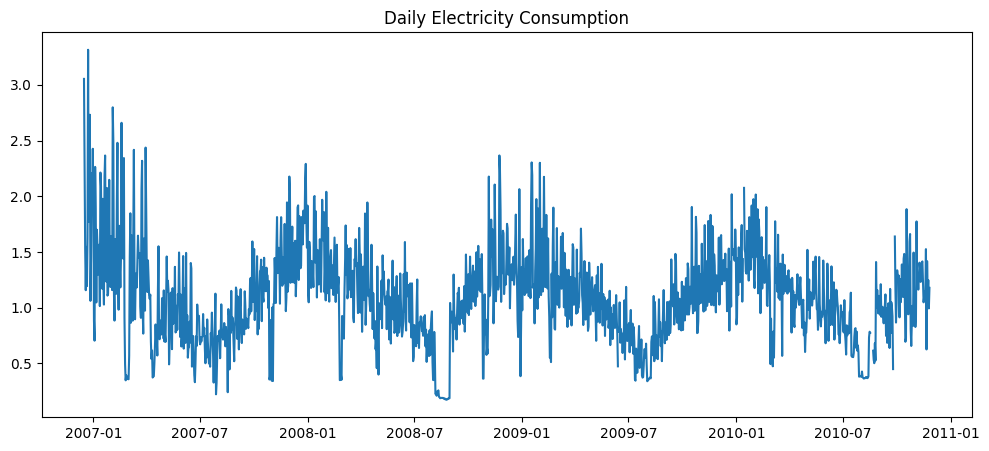

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_data)
plt.title("Daily Electricity Consumption")
plt.show()

# **ROLLING MEAN**

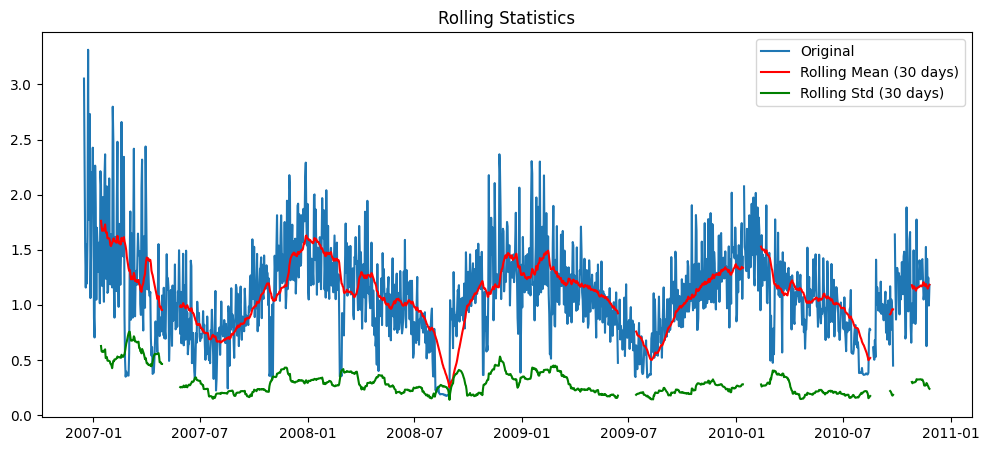

In [ ]:
rolling_mean = daily_data.rolling(window=30).mean()
rolling_std = daily_data.rolling(window=30).std()

plt.figure(figsize=(12,5))
plt.plot(daily_data, label='Original')
plt.plot(rolling_mean, label='Rolling Mean (30 days)', color='red')
plt.plot(rolling_std, label='Rolling Std (30 days)', color='green')
plt.legend()
plt.title("Rolling Statistics")
plt.show()

# **Stationary Test**

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_data.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -3.684227530202004
p-value: 0.004340557878211848
Critical Value (1%): -3.434996272992033
Critical Value (5%): -2.863592002111143
Critical Value (10%): -2.5678624767365825


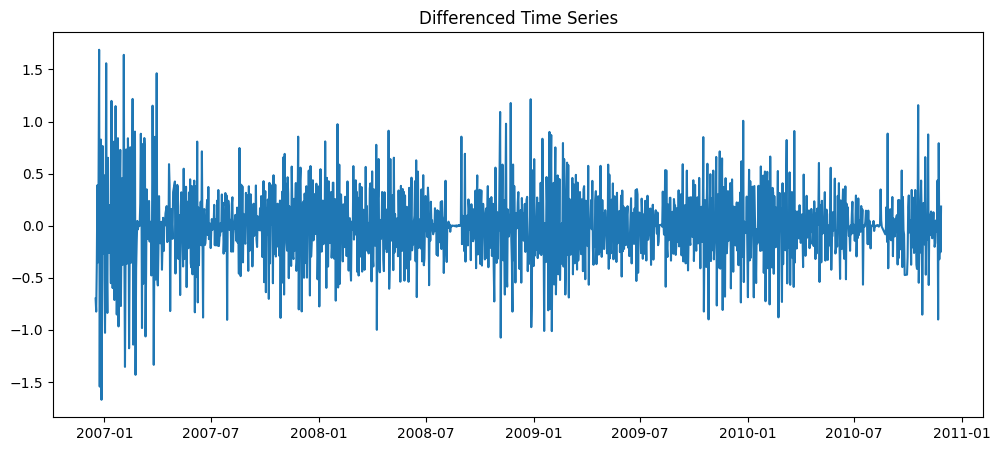

In [ ]:
diff_data = daily_data.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(diff_data)
plt.title("Differenced Time Series")
plt.show()

## **ACF AND PACF**

<Figure size 1200x500 with 0 Axes>

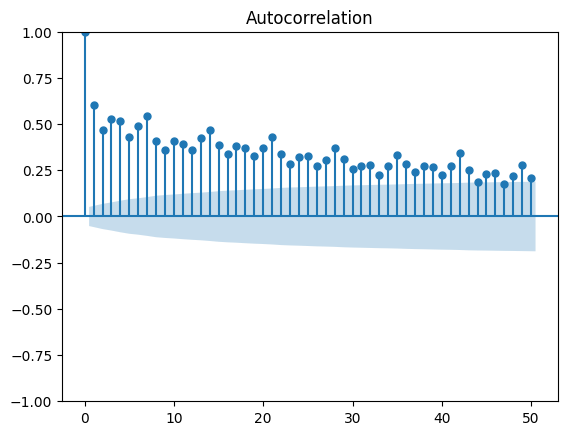

<Figure size 1200x500 with 0 Axes>

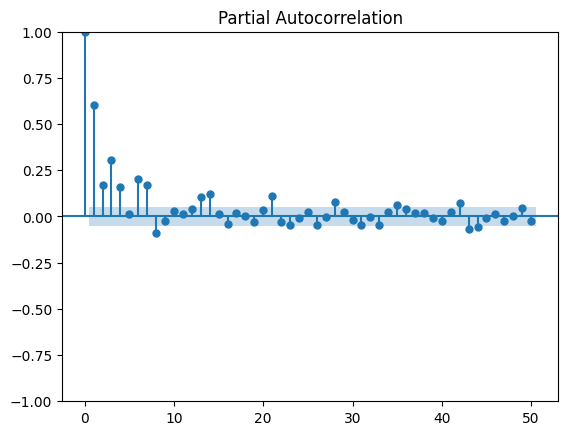

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(daily_data.dropna(), lags=50)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(daily_data.dropna(), lags=50)
plt.show()

## **TIME SERIES DECOMPOSITION**



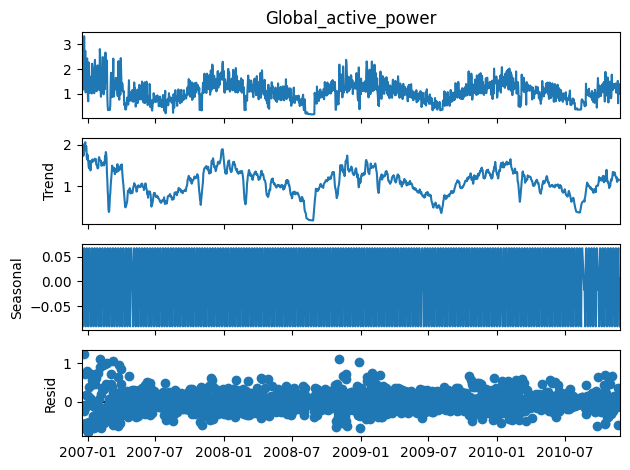

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_data.dropna(),
    model='additive',
    period=7   # weekly seasonality
)

decomposition.plot()
plt.show()

In [ ]:
train_size = int(len(daily_data) * 0.8)

train = daily_data[:train_size]
test = daily_data[train_size:]

In [ ]:
!pip install statsmodels

## **ARIMA MODEL**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))  # (p,d,q)
model_fit = model.fit()

print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                 1153
Model:                  ARIMA(5, 1, 0)   Log Likelihood                -314.325
Date:                 Fri, 01 May 2026   AIC                            640.650
Time:                         13:08:58   BIC                            670.945
Sample:                     12-16-2006   HQIC                           652.085
                          - 02-10-2010                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5552      0.023    -24.576      0.000      -0.599      -0.511
ar.L2         -0.5791      0.026    -22.294      0.000      -0.630      -0.528
ar.L3         -0.3507      0.028    -12.341 

**MAKE PREDICTIONS**

In [ ]:
predictions = model_fit.forecast(steps=len(test))

# **RESULTS**

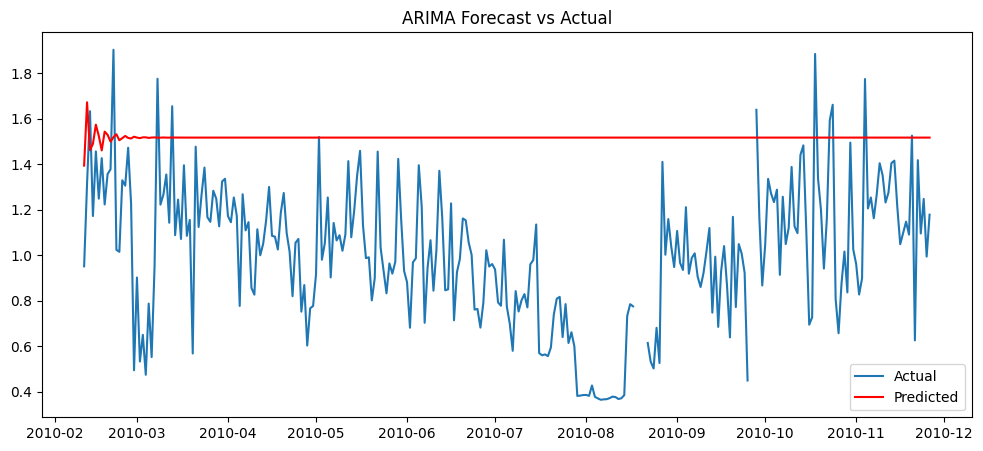

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(test, label='Actual')
plt.plot(predictions, label='Predicted', color='red')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [ ]:
import pandas as pd

# make sure predictions align with test index
predictions = pd.Series(predictions, index=test.index)

# create evaluation dataframe
df_eval = pd.concat([test, predictions], axis=1)
df_eval.columns = ['Actual', 'Predicted']

# remove NaNs
df_eval = df_eval.dropna()

print("Rows after cleaning:", len(df_eval))

Rows after cleaning: 283


**EVALUATION**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(df_eval['Actual'], df_eval['Predicted'])
rmse_arima = np.sqrt(mean_squared_error(df_eval['Actual'], df_eval['Predicted']))

print("MAE:", mae_arima)
print("RMSE:", rmse_arima)

MAE: 0.5270980276787681
RMSE: 0.5997170417866605


In [ ]:
print(test.isnull().sum())
print(pd.Series(predictions).isnull().sum())

6
0


In [ ]:
predictions = pd.Series(predictions, index=test.index)

In [ ]:
df_eval = pd.concat([test, predictions], axis=1)
df_eval.columns = ['Actual', 'Predicted']

df_eval = df_eval.dropna()

## **LSTM MODEL**

## **BUILD LSTM MODEL**

In [ ]:
# ─────────────────────────────────────────
# LSTM STEP 0: Clean Data
# ─────────────────────────────────────────
daily_clean = daily_data.copy()
daily_clean = pd.to_numeric(daily_clean, errors='coerce')
daily_clean = daily_clean.dropna()
daily_clean = daily_clean[daily_clean > 0]

print("Length after cleaning:", len(daily_clean))
print("NaNs:", daily_clean.isnull().sum())
print("Min:", daily_clean.min(), "| Max:", daily_clean.max())

# ─────────────────────────────────────────
# LSTM STEP 1: Scale
# ─────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(daily_clean.values.reshape(-1, 1))

print("NaNs in scaled:", np.isnan(scaled_data).sum())
print("Min:", scaled_data.min(), "| Max:", scaled_data.max())

# ─────────────────────────────────────────
# LSTM STEP 2: Create Sequences
# ─────────────────────────────────────────
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(scaled_data, seq_length)

print("X shape:", X.shape, "| NaNs:", np.isnan(X).sum())
print("y shape:", y.shape, "| NaNs:", np.isnan(y).sum())



Length after cleaning: 1433
NaNs: 0
Min: 0.17381805555555555 | Max: 3.314851388888889
NaNs in scaled: 0
Min: 0.0 | Max: 0.9999999999999999
X shape: (1403, 30, 1) | NaNs: 0
y shape: (1403, 1) | NaNs: 0


In [ ]:
# ─────────────────────────────────────────
# LSTM STEP 3: Train-Test Split
# ─────────────────────────────────────────
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:",  X_test.shape,  "| y_test:",  y_test.shape)

X_train: (1122, 30, 1) | y_train: (1122, 1)
X_test: (281, 30, 1) | y_test: (281, 1)


In [ ]:
# ─────────────────────────────────────────
# LSTM STEP 4: Build Model
# ─────────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

model = Sequential([
    Input(shape=(seq_length, 1)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ─────────────────────────────────────────
# LSTM STEP 5: Train
# ─────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0112 - val_loss: 0.0060
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0109 - val_loss: 0.0064
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0109 - val_loss: 0.0060
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0108 - val_loss: 0.0063
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0105 - val_loss: 0.0061
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0109 - val_loss: 0.0069


# ***PREDICTIONS***

In [ ]:
# ─────────────────────────────────────────
# LSTM STEP 6: Predict
# ─────────────────────────────────────────
predictions_scaled = model.predict(X_test)

predictions   = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test)

y_true = y_test_actual.flatten()
y_pred = predictions.flatten()

print("y_true length:", len(y_true))
print("y_pred length:", len(y_pred))
print("NaNs in y_true:", np.isnan(y_true).sum())
print("NaNs in y_pred:", np.isnan(y_pred).sum())
print("Sample actual:",    y_true[:5])
print("Sample predicted:", y_pred[:5])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_true length: 281
y_pred length: 281
NaNs in y_true: 0
NaNs in y_pred: 0
Sample actual: [1.633025   1.17213204 1.45634167 1.24844167 1.42677778]
Sample predicted: [1.3615683 1.3665975 1.3408916 1.3392262 1.3236077]


In [ ]:
# ─────────────────────────────────────────
# LSTM STEP 7: Evaluate
# ─────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("LSTM MAE: ", round(mae, 4))
print("LSTM RMSE:", round(rmse, 4))

LSTM MAE:  0.1806
LSTM RMSE: 0.2432


## **MODEL EVALUATION**

# **MODEL COMPARISON**

In [ ]:
arima_mae = mae_arima
arima_rmse = rmse_arima

lstm_mae = mae
lstm_rmse = rmse

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [arima_mae, lstm_mae],
    "RMSE": [arima_rmse, lstm_rmse]
})

print(results)

   Model       MAE      RMSE
0  ARIMA  0.527098  0.599717
1   LSTM  0.180604  0.243158


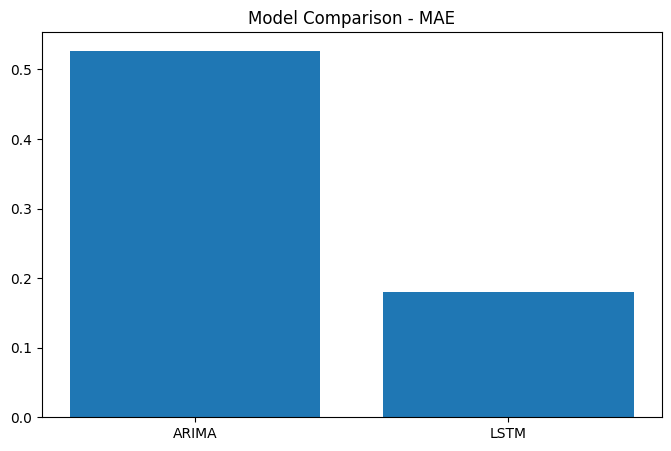

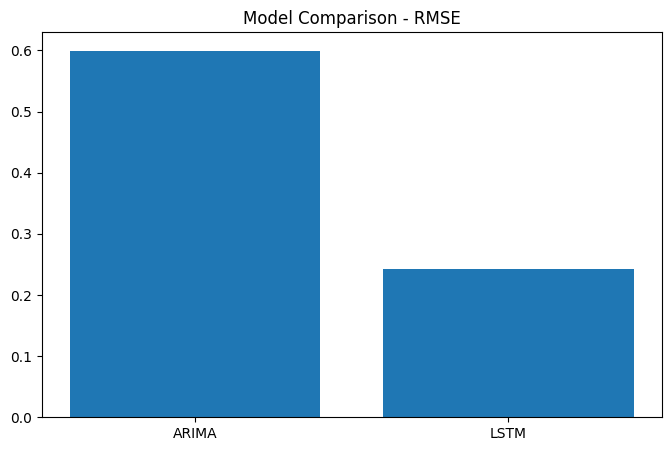

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison - MAE")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("Model Comparison - RMSE")
plt.show()

In [ ]:
# ─────────────────────────────────────────
# EVALUATION METRICS — ARIMA vs LSTM
# ─────────────────────────────────────────
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

arima_mae  = mae_arima
arima_rmse = rmse_arima
arima_mape = mean_absolute_percentage_error(df_eval['Actual'], df_eval['Predicted'])

lstm_mae  = mae
lstm_rmse = rmse
lstm_mape = mean_absolute_percentage_error(y_true, y_pred)

print("=" * 40)
print(f"{'Metric':<12} {'ARIMA':>10} {'LSTM':>10}")
print("=" * 40)
print(f"{'MAE':<12} {arima_mae:>10.4f} {lstm_mae:>10.4f}")
print(f"{'RMSE':<12} {arima_rmse:>10.4f} {lstm_rmse:>10.4f}")
print(f"{'MAPE (%)':<12} {arima_mape:>10.2f} {lstm_mape:>10.2f}")
print("=" * 40)

Metric            ARIMA       LSTM
MAE              0.5271     0.1806
RMSE             0.5997     0.2432
MAPE (%)          72.45      21.19


# GRAPHICAL COMPARISON — ARIMA vs LSTM

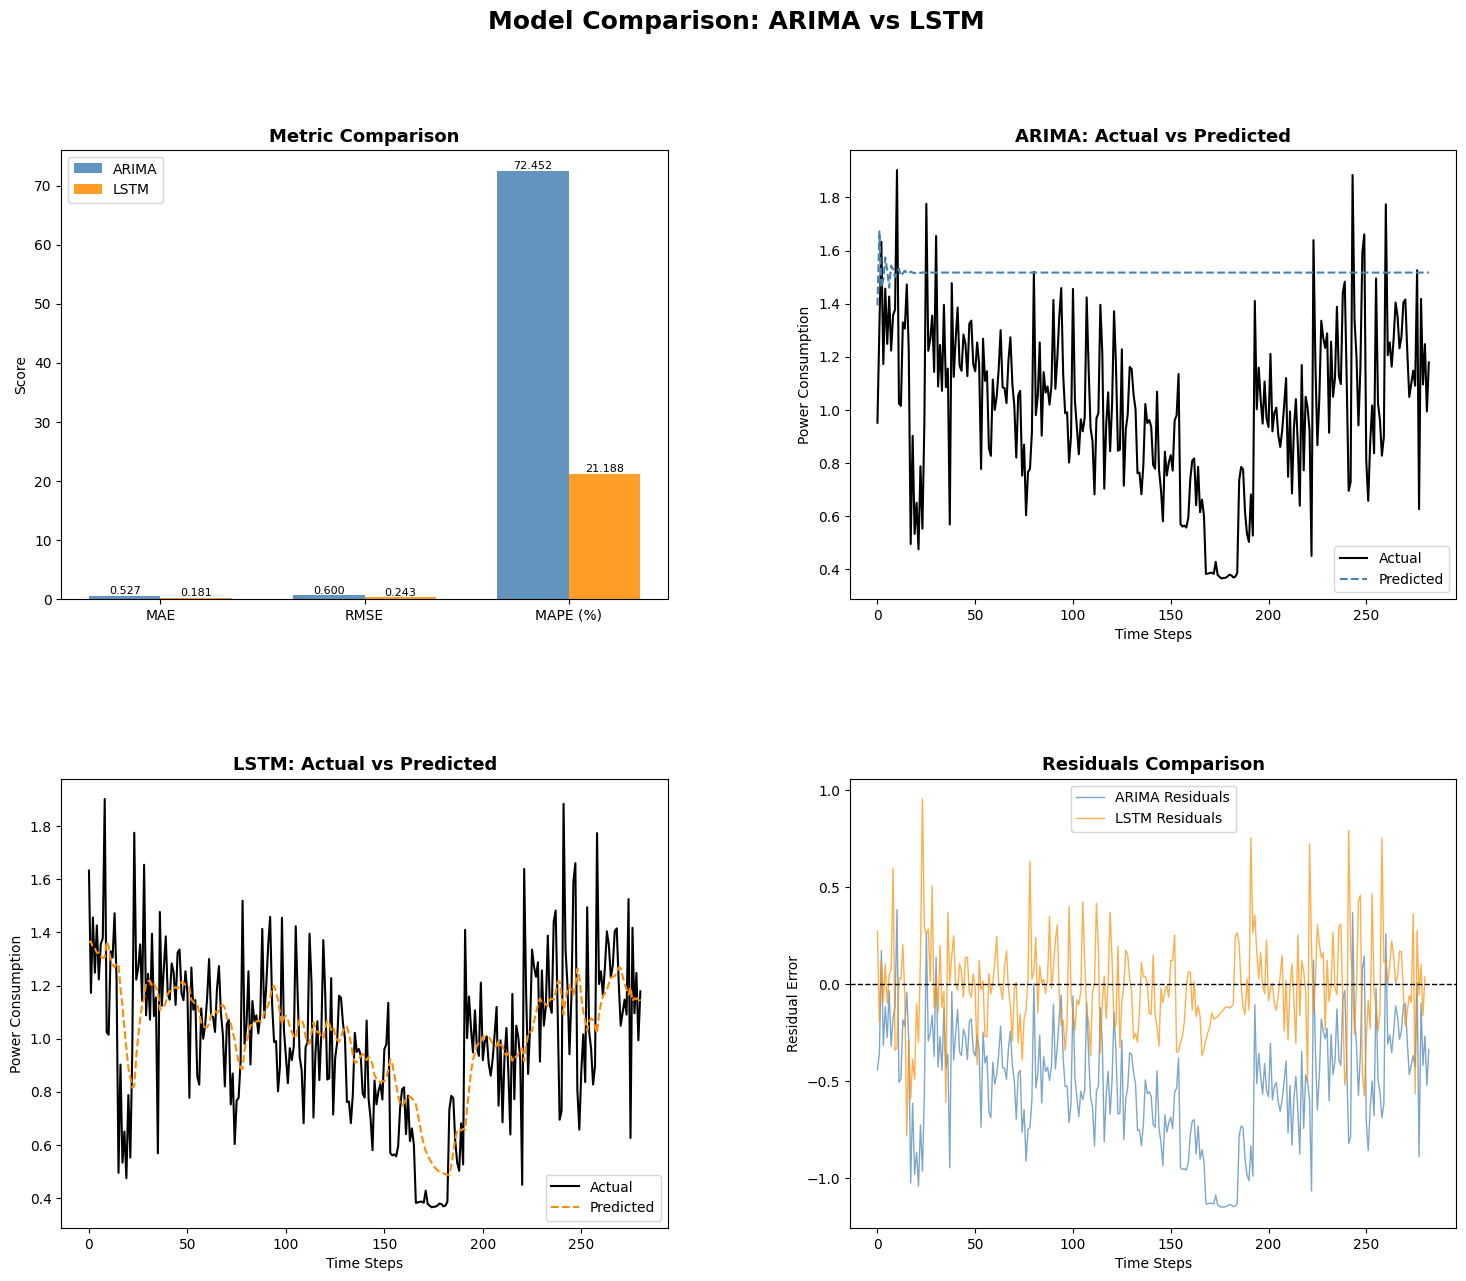

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Model Comparison: ARIMA vs LSTM", fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Plot 1: Bar chart
ax1 = fig.add_subplot(gs[0, 0])
metrics_list = ['MAE', 'RMSE', 'MAPE (%)']
arima_vals   = [arima_mae, arima_rmse, arima_mape]
lstm_vals    = [lstm_mae,  lstm_rmse,  lstm_mape]
x = np.arange(len(metrics_list))
width = 0.35
bars1 = ax1.bar(x - width/2, arima_vals, width, label='ARIMA', color='steelblue',  alpha=0.85)
bars2 = ax1.bar(x + width/2, lstm_vals,  width, label='LSTM',  color='darkorange', alpha=0.85)
ax1.set_title('Metric Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_list)
ax1.set_ylabel('Score')
ax1.legend()
for bar in list(bars1) + list(bars2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Plot 2: ARIMA Actual vs Predicted
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_eval['Actual'].values,    label='Actual',    color='black',     linewidth=1.5)
ax2.plot(df_eval['Predicted'].values, label='Predicted', color='steelblue', linewidth=1.5, linestyle='--')
ax2.set_title('ARIMA: Actual vs Predicted', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Power Consumption')
ax2.legend()

# Plot 3: LSTM Actual vs Predicted
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(y_true, label='Actual',    color='black',      linewidth=1.5)
ax3.plot(y_pred, label='Predicted', color='darkorange', linewidth=1.5, linestyle='--')
ax3.set_title('LSTM: Actual vs Predicted', fontsize=13, fontweight='bold')
ax3.set_xlabel('Time Steps')
ax3.set_ylabel('Power Consumption')
ax3.legend()

# Plot 4: Residuals
ax4 = fig.add_subplot(gs[1, 1])
arima_residuals = df_eval['Actual'].values - df_eval['Predicted'].values
lstm_residuals  = y_true - y_pred
ax4.plot(arima_residuals, label='ARIMA Residuals', color='steelblue',  alpha=0.7, linewidth=1)
ax4.plot(lstm_residuals,  label='LSTM Residuals',  color='darkorange', alpha=0.7, linewidth=1)
ax4.axhline(0, color='black', linewidth=1, linestyle='--')
ax4.set_title('Residuals Comparison', fontsize=13, fontweight='bold')
ax4.set_xlabel('Time Steps')
ax4.set_ylabel('Residual Error')
ax4.legend()

plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_931/746828517.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


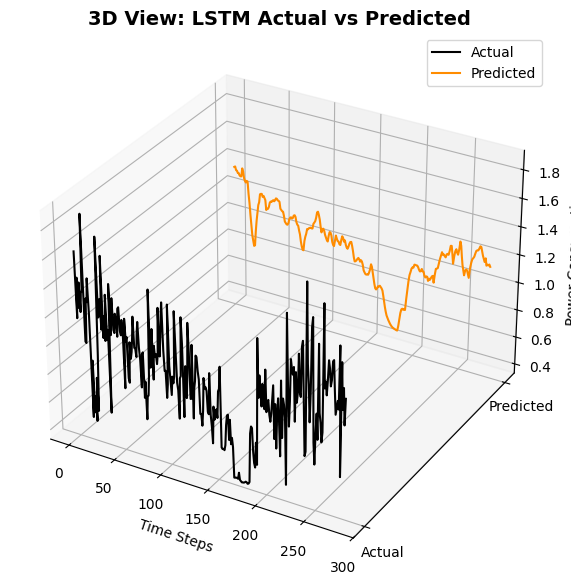

In [ ]:
# ─────────────────────────────────────────
# 3D PLOT 1: LSTM Actual vs Predicted
# ─────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')
time_steps = np.arange(len(y_true))

ax.plot(time_steps, y_true, zs=0, zdir='y', label='Actual',    color='black',      linewidth=1.5)
ax.plot(time_steps, y_pred, zs=1, zdir='y', label='Predicted', color='darkorange', linewidth=1.5)

ax.set_xlabel('Time Steps')
ax.set_zlabel('Power Consumption')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual', 'Predicted'])
ax.set_title('3D View: LSTM Actual vs Predicted', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_931/3311221622.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


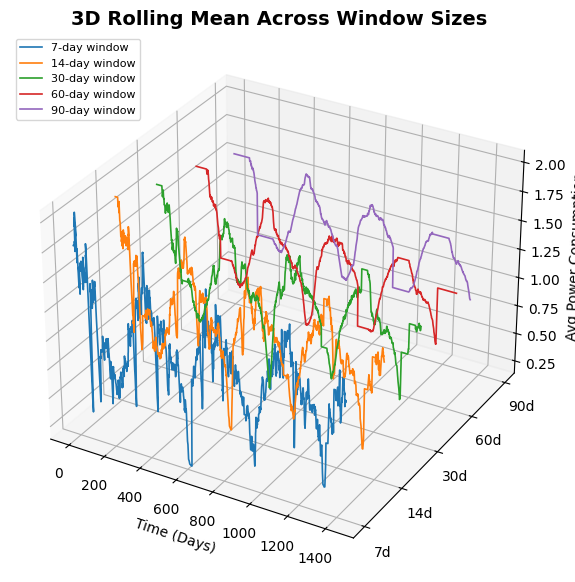

In [ ]:
# 3D PLOT 2: Rolling Mean Surface

windows   = [7, 14, 30, 60, 90]
time_axis = np.arange(len(daily_data))

fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(111, projection='3d')

for i, w in enumerate(windows):
    roll = daily_data.rolling(window=w).mean().bfill()
    ax.plot(time_axis, roll.values, zs=i, zdir='y',
            label=f'{w}-day window', linewidth=1.2)

ax.set_xlabel('Time (Days)')
ax.set_zlabel('Avg Power Consumption')
ax.set_yticks(range(len(windows)))
ax.set_yticklabels([f'{w}d' for w in windows])
ax.set_title('3D Rolling Mean Across Window Sizes', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# **CONCLUSION**

In [ ]:
# CONCLUSION
print("=" * 50)
print("     TIME SERIES FORECASTING — SUMMARY")
print("=" * 50)
print(f"\n{'Model':<10} {'MAE':>10} {'RMSE':>10} {'MAPE (%)':>10}")
print("-" * 45)
print(f"{'ARIMA':<10} {arima_mae:>10.4f} {arima_rmse:>10.4f} {arima_mape:>10.2f}")
print(f"{'LSTM':<10} {lstm_mae:>10.4f} {lstm_rmse:>10.4f} {lstm_mape:>10.2f}")
print("=" * 50)

best = "LSTM" if lstm_mae < arima_mae else "ARIMA"
print(f"\n✅ Best performing model (by MAE): {best}")
print("\nDataset : Individual Household Electric Power Consumption")
print("Models  : ARIMA(5,1,0)  |  LSTM (2 layers, 50 units)")
print("Metrics : MAE, RMSE, MAPE")
print("=" * 50)

     TIME SERIES FORECASTING — SUMMARY

Model             MAE       RMSE   MAPE (%)
---------------------------------------------
ARIMA          0.5271     0.5997      72.45
LSTM           0.1806     0.2432      21.19

✅ Best performing model (by MAE): LSTM

Dataset : Individual Household Electric Power Consumption
Models  : ARIMA(5,1,0)  |  LSTM (2 layers, 50 units)
Metrics : MAE, RMSE, MAPE
